<a href="https://colab.research.google.com/github/Divya4325/-Diamond-Dynamics-Price-Prediction-and-Market-Segmentation/blob/main/Diamond_Dynamics_Price_Prediction_and_Market_Segmentation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Data Collection**

In [ ]:
! pip install scikit-learn==1.8.0

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.9/8.9 MB 51.9 MB/s eta 0:00:00
  Attempting uninstall: scikit-learn
    Found existing installation: scikit-learn 1.6.1
    Uninstalling scikit-learn-1.6.1:
      Successfully uninstalled scikit-learn-1.6.1


In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import pandas as pd

In [3]:
path='/content/drive/MyDrive/diamonds.csv'
df=pd.read_csv(path)

In [4]:
df.head()

,carat,cut,color,clarity,depth,table,price,x,y,z
0,0.23,Ideal,E,SI2,61.5,55.0,326,3.95,3.98,2.43
1,0.21,Premium,E,SI1,59.8,61.0,326,3.89,3.84,2.31
2,0.23,Good,E,VS1,56.9,65.0,327,4.05,4.07,2.31
3,0.29,Premium,I,VS2,62.4,58.0,334,4.20,4.23,2.63
4,0.31,Good,J,SI2,63.3,58.0,335,4.34,4.35,2.75


# **Data Understanding**

***Shape of the dataset***

In [ ]:
df.shape

(53940, 10)

***Info for each columns***

In [ ]:
df.info() #Information of the dataset

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 53940 entries, 0 to 53939
Data columns (total 10 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   carat    53940 non-null  float64
 1   cut      53940 non-null  object 
 2   color    53940 non-null  object 
 3   clarity  53940 non-null  object 
 4   depth    53940 non-null  float64
 5   table    53940 non-null  float64
 6   price    53940 non-null  int64  
 7   x        53940 non-null  float64
 8   y        53940 non-null  float64
 9   z        53940 non-null  float64
dtypes: float64(6), int64(1), object(3)
memory usage: 4.1+ MB


In [ ]:
df.columns

Index(['carat', 'cut', 'color', 'clarity', 'depth', 'table', 'price', 'x', 'y',
       'z'],
      dtype='object')

***Describe the each columns***

In [ ]:
df.describe() #Description of the dataset

,carat,depth,table,price,x,y,z
count,53940.000000,53940.000000,53940.000000,53940.000000,53940.000000,53940.000000,53940.000000
mean,0.797940,61.749405,57.457184,3932.799722,5.731157,5.734526,3.538734
std,0.474011,1.432621,2.234491,3989.439738,1.121761,1.142135,0.705699
min,0.200000,43.000000,43.000000,326.000000,0.000000,0.000000,0.000000
25%,0.400000,61.000000,56.000000,950.000000,4.710000,4.720000,2.910000
50%,0.700000,61.800000,57.000000,2401.000000,5.700000,5.710000,3.530000
75%,1.040000,62.500000,59.000000,5324.250000,6.540000,6.540000,4.040000
max,5.010000,79.000000,95.000000,18823.000000,10.740000,58.900000,31.800000


***Checking Duplicates for the dataset***

In [5]:
df.duplicated().sum()

np.int64(146)

In [6]:
df = df.drop_duplicates()

In [7]:
print(df.duplicated().sum())

0


***Checking Missing values for the dataset***

In [8]:
df.isnull().sum()

,0
carat,0
cut,0
color,0
clarity,0
depth,0
table,0
price,0
x,0
y,0
z,0


*Convert zero or invalid values in x, y, z by using median*

In [9]:
cols=['x','y','z']
df[cols]=df[cols].replace(0,df[cols].median())

***Detecting the Outliers***

In [10]:
import seaborn as sns
import matplotlib.pyplot as plt

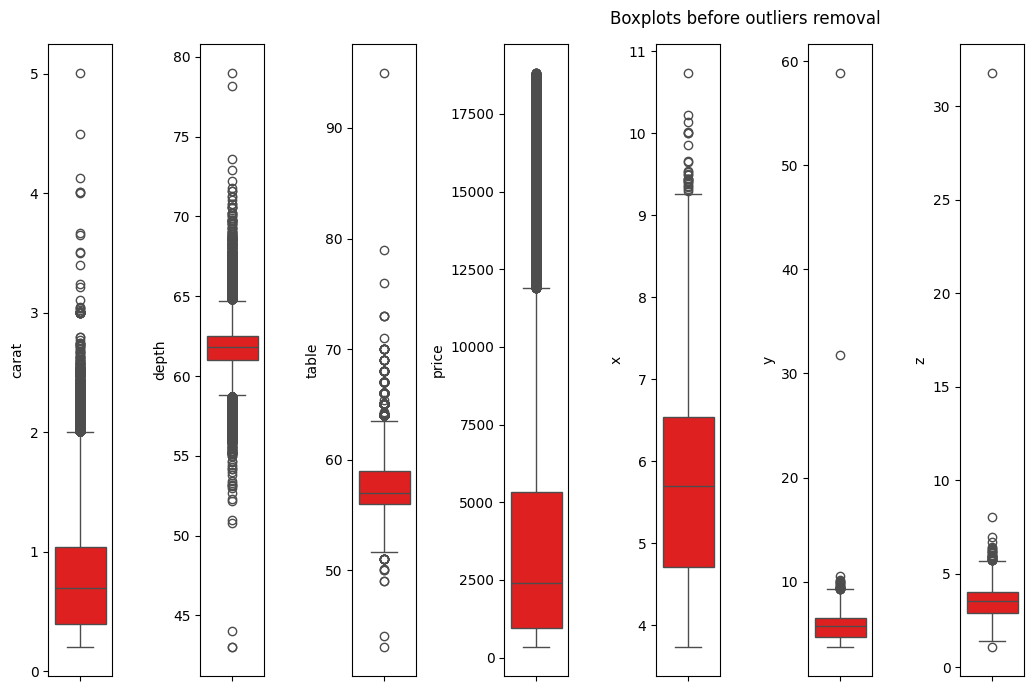

In [11]:
numerical_columns=['carat','depth','table','price','x','y','z']
plt.figure(figsize=(15,7))
plt.suptitle("Boxplots before outliers removal")
for i in range(0,len(numerical_columns)):
 plt.subplot(1,10,i+1)
 sns.boxplot(y=df[numerical_columns[i]],color='red')
plt.tight_layout()

***Detecting Skewness***

In [12]:
numerical_columns=['carat','depth','table','price','x','y','z']
skewness=(df[numerical_columns].skew())
skewness

,0
carat,1.113651
depth,-0.114250
table,0.792227
price,1.618240
x,0.397075
y,2.468675
z,1.589604


In [13]:
import seaborn as sns
import matplotlib.pyplot as plt

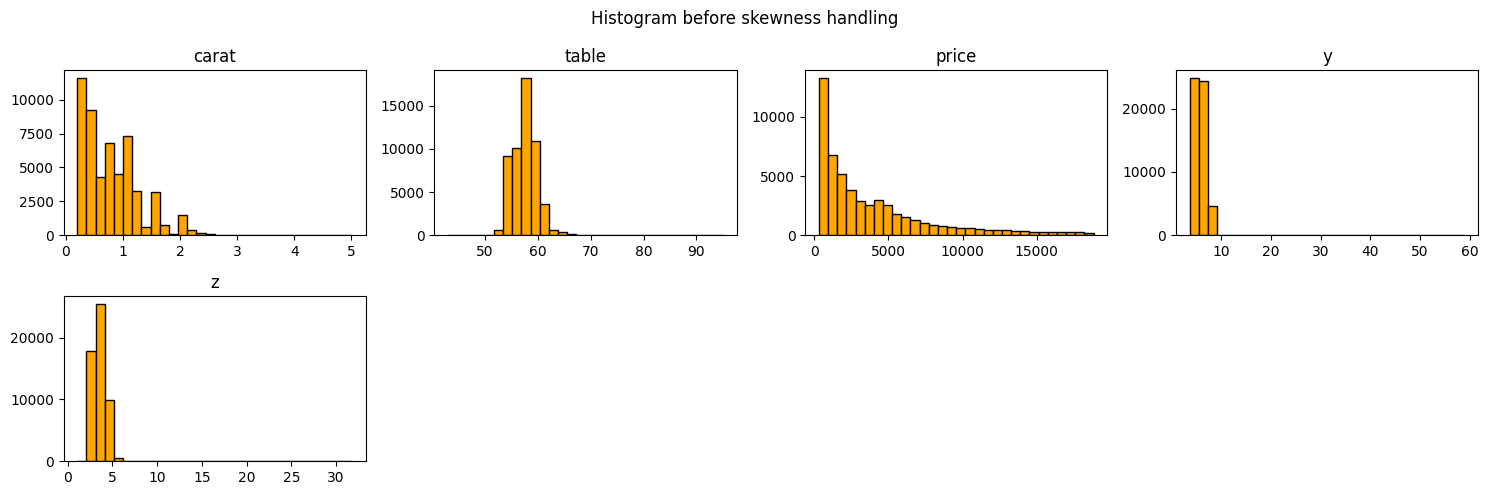

In [14]:
skewed_cols=skewness[abs(skewness) > 0.5].index
plt.figure(figsize=(15,5))
for i, col in enumerate(skewed_cols,1):
  plt.suptitle("Histogram before skewness handling")
  plt.subplot(2,4,i)
  plt.hist(df[col],bins=30,color='orange',edgecolor='black')
  plt.title(f"{col}")
plt.tight_layout()
plt.show()

**Columns---- x,depth**

*These columns does not require skewness because there values between -0.5 To 0.5*

**Column-table is moderately skewned so i didn't handle this**

**Columns----carat,price,y,z**

***These columns need to handle skewness because there values exceed beyond -0.5 To 0.5 ***

# **Analyses & Visualizations**

### ***1). Distribution plots for price, carat, x, y, z***

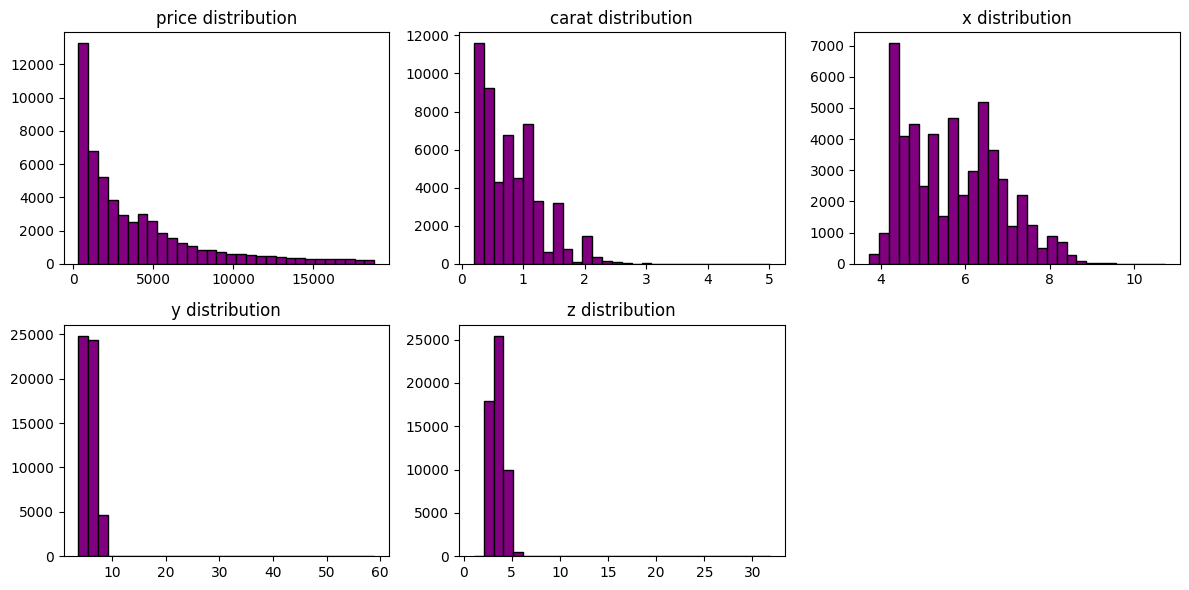

In [ ]:
import matplotlib.pyplot as plt
cols=['price','carat','x','y','z']
plt.figure(figsize=(12,6))
for i,col in enumerate(cols,1):
  plt.subplot(2,3,i)
  plt.hist(df[col],bins=30, color='purple',edgecolor='black')
  plt.title(f"{col} distribution")
plt.tight_layout()
plt.show()

# **Count plots for categorical features (cut, color, clarity)**


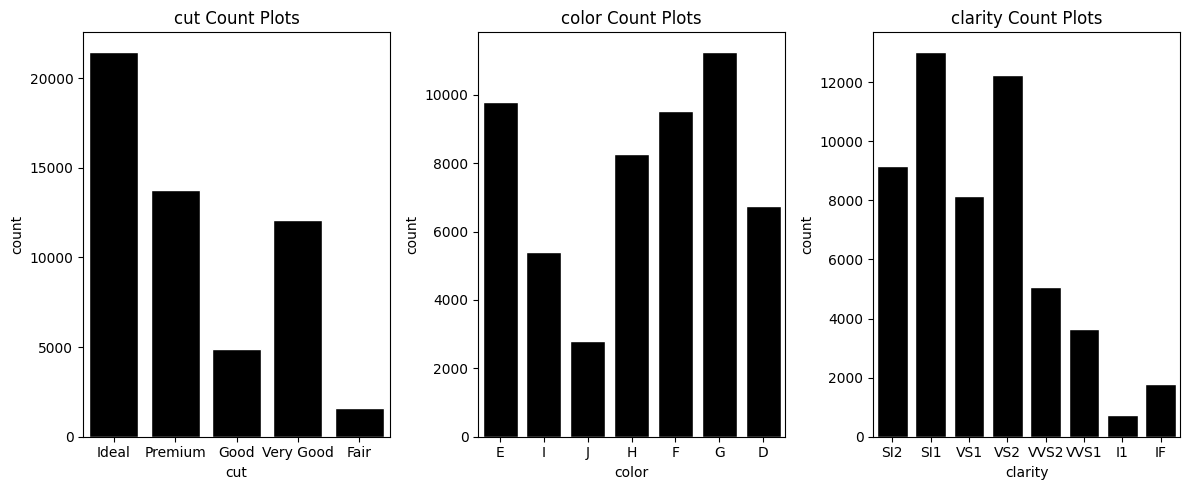

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
cat_cols=['cut','color','clarity']
plt.figure(figsize=(12,5))
for i,col in enumerate(cat_cols,1):
  plt.subplot(1,3,i)
  sns.countplot(x=df[col],color='black',edgecolor='white')
  plt.title(f"{col} Count Plots")
plt.tight_layout()
plt.show()

# **Price variation with carat, cut, color, clarity using boxplots**


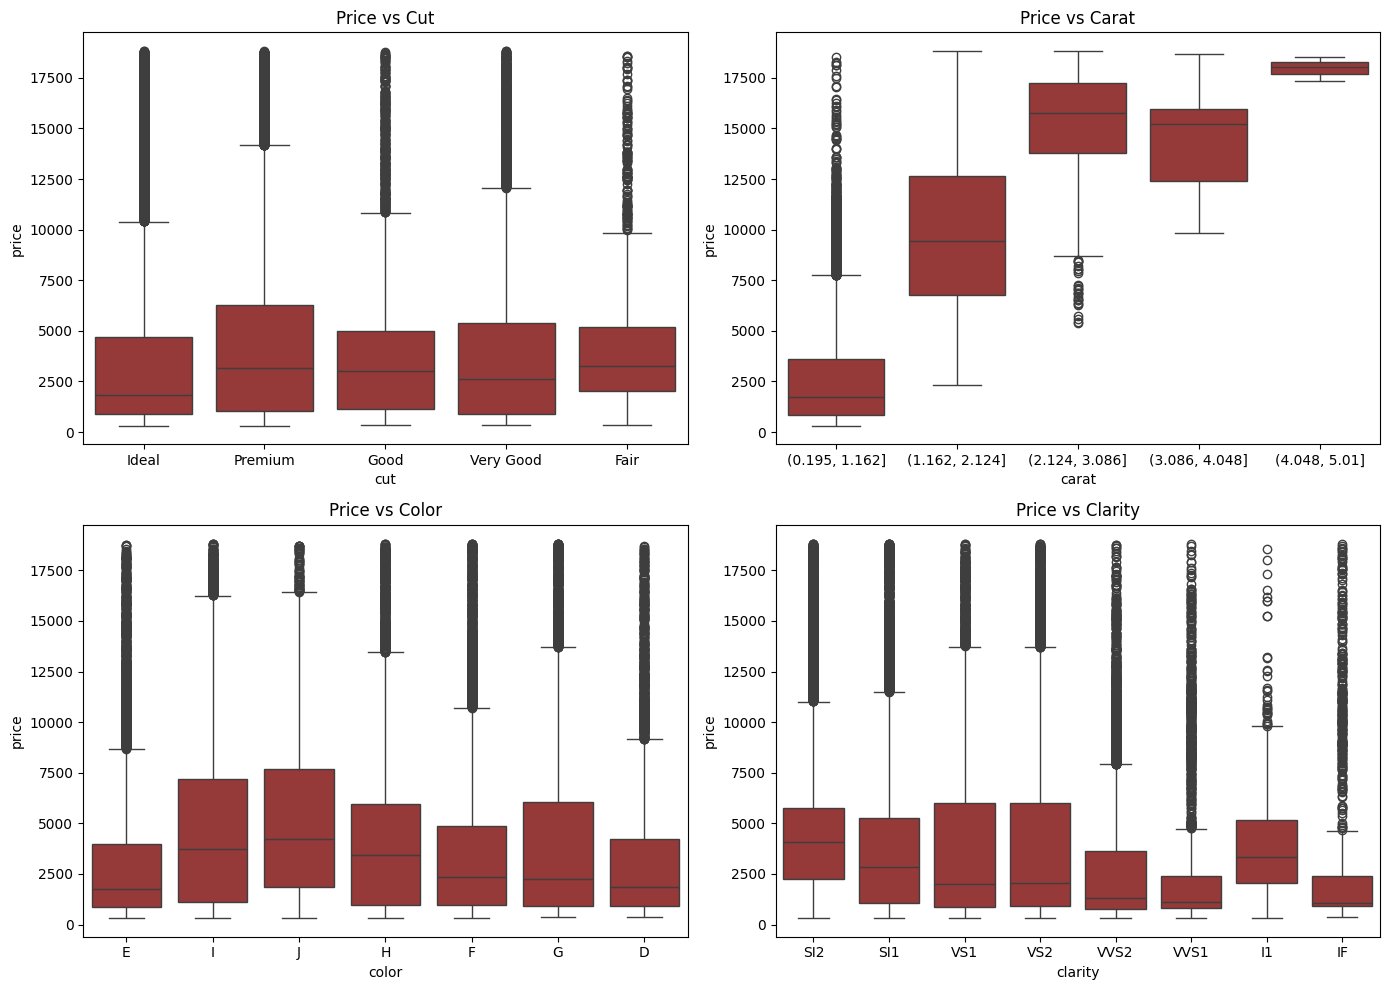

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
plt.figure(figsize=(14,10))

#Cut
plt.subplot(2,2,1)
sns.boxplot(x=df['cut'],y=df['price'],color='brown')
plt.title("Price vs Cut")

#Carat
plt.subplot(2,2,2)
sns.boxplot(x=pd.cut(df['carat'],bins=5),y=df['price'],color='brown')
plt.title("Price vs Carat")

#Color
plt.subplot(2,2,3)
sns.boxplot(x=df['color'],y=df['price'],color='brown')
plt.title("Price vs Color")

#Clarity
plt.subplot(2,2,4)
sns.boxplot(x=df['clarity'],y=df['price'],color='brown')
plt.title("Price vs Clarity")

plt.tight_layout()
plt.show()

# **Correlation heatmap for numerical features**

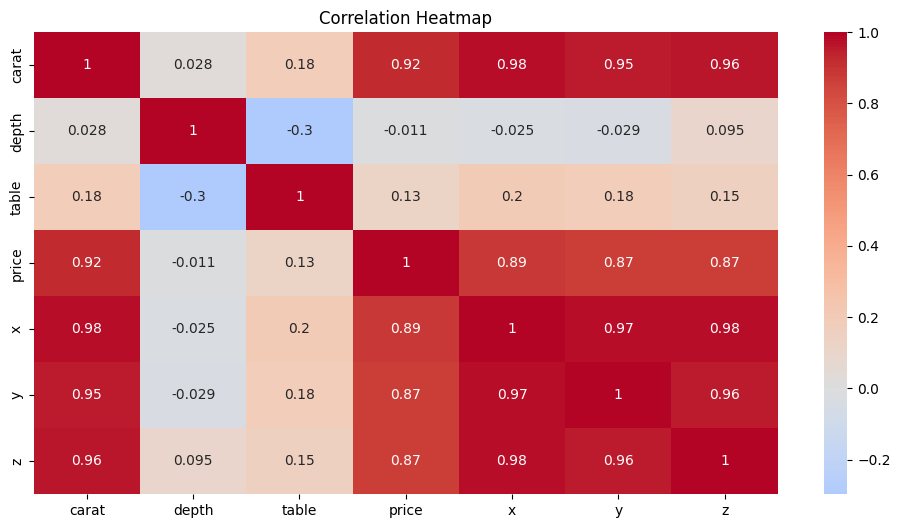

In [ ]:
numerical_columns=['carat','depth','table','price','x','y','z']
import seaborn as sns
import matplotlib.pyplot as plt
plt.figure(figsize=(12,6))
sns.heatmap(df[numerical_columns].corr(),cmap='coolwarm',annot=True,center=0)
plt.title("Correlation Heatmap")
plt.show()

# **Scatterplot matrix for carat, x, y, z, and price**


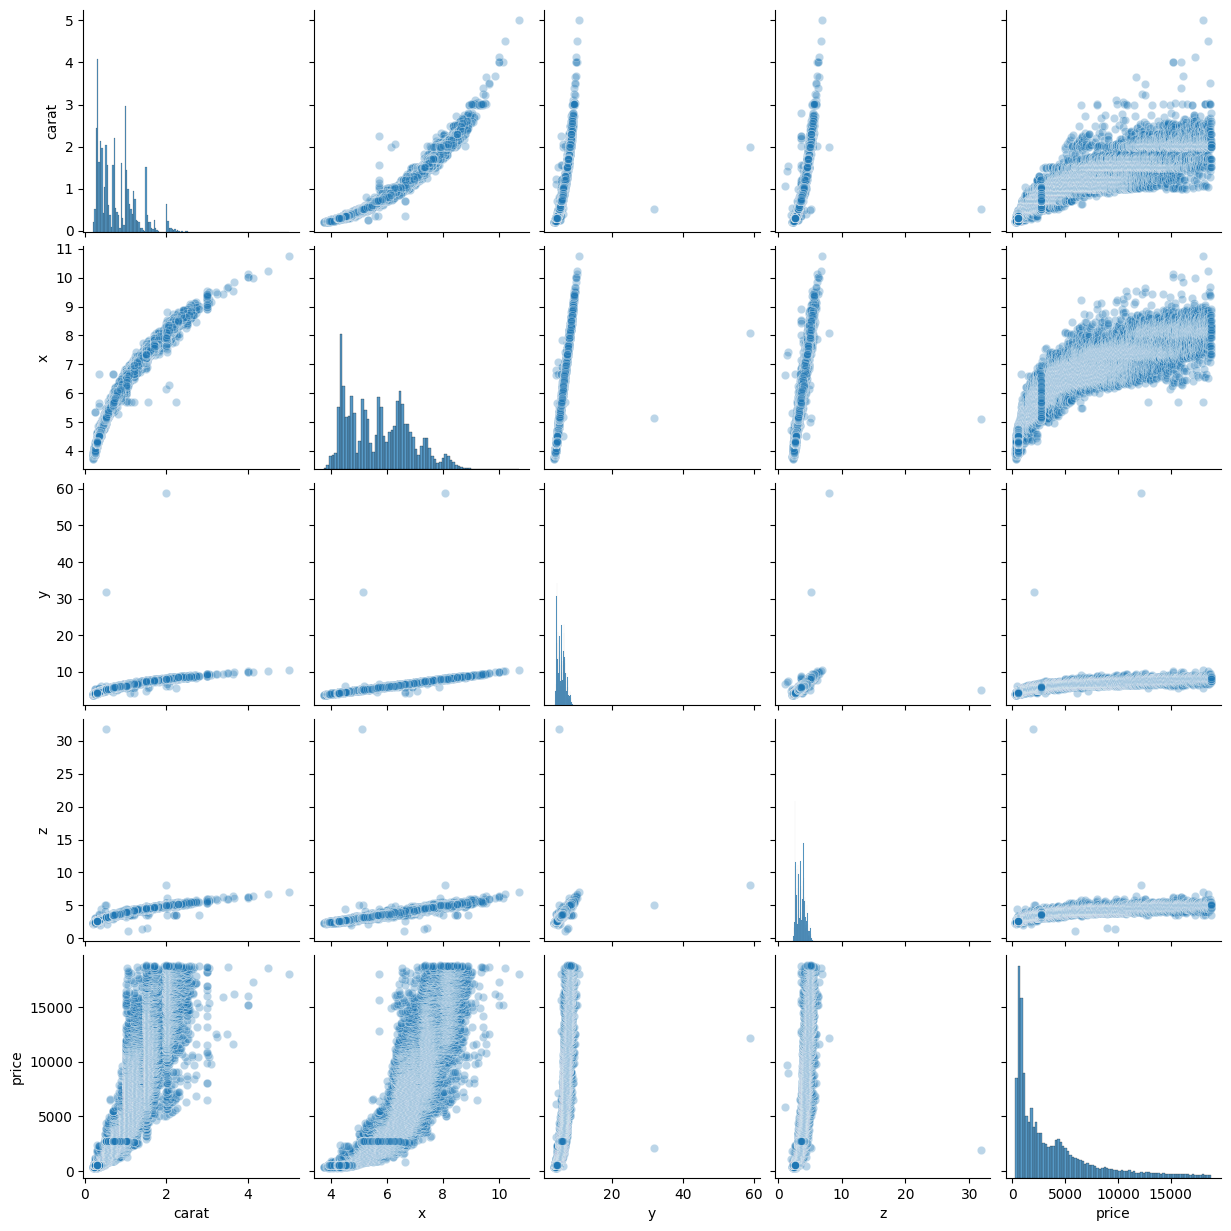

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
cols=['carat','x','y','z','price']
sns.pairplot(df[cols],plot_kws={'alpha':0.3})

plt.show()

# **Pairwise relationships using sns.pairplot()**

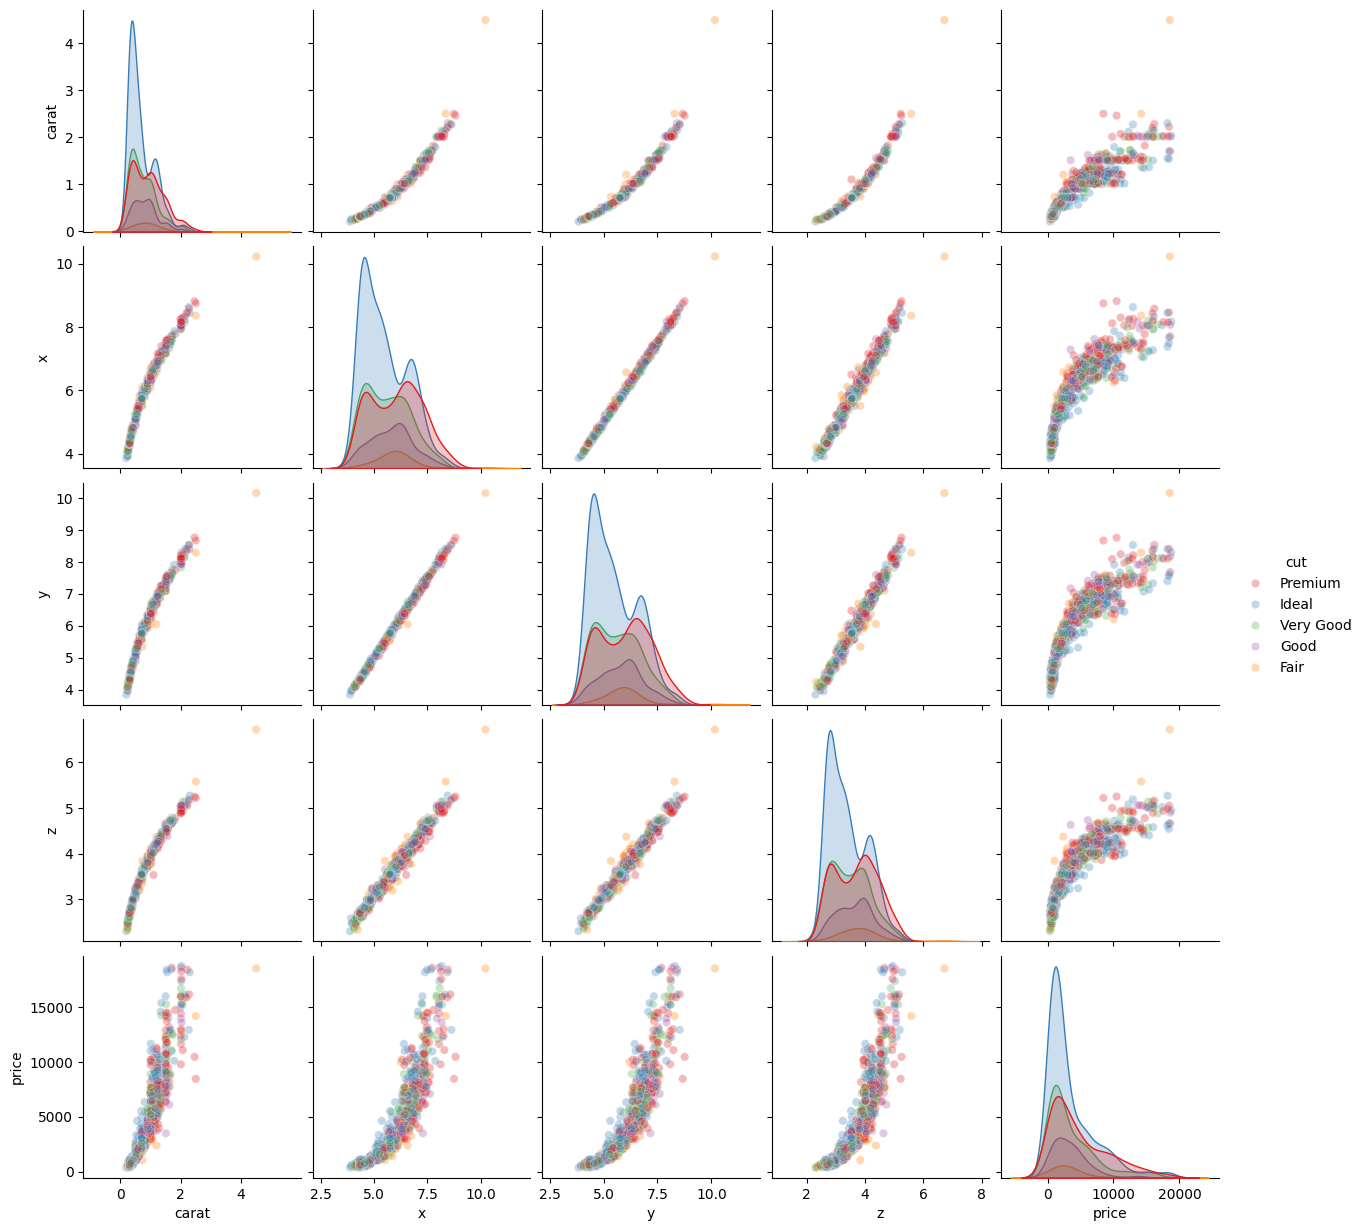

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
cols=['carat','x','y','z','price','cut']
sns.pairplot(df[cols].sample(1000),
    hue='cut',
    palette='Set1',diag_kind= 'kde',plot_kws={'alpha':0.3})

plt.show()

# **Carat vs. price regression lineplot**


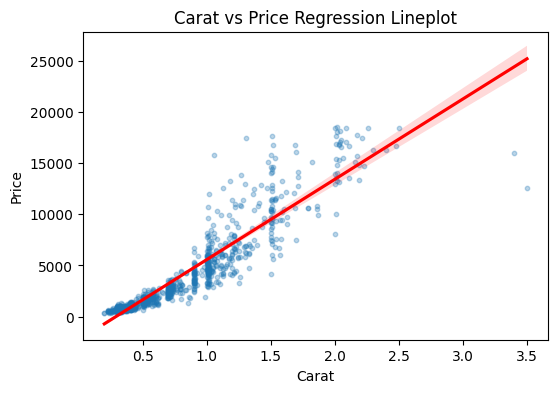

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
sns.regplot(x='carat',y='price',data=df.sample(1000),scatter_kws={'s':10,'alpha':0.3},line_kws={'color':'red'})

plt.title("Carat vs Price Regression Lineplot")
plt.xlabel("Carat")
plt.ylabel("Price")
plt.show()

# **Average price per cut, color, clarity categories using bar plots**


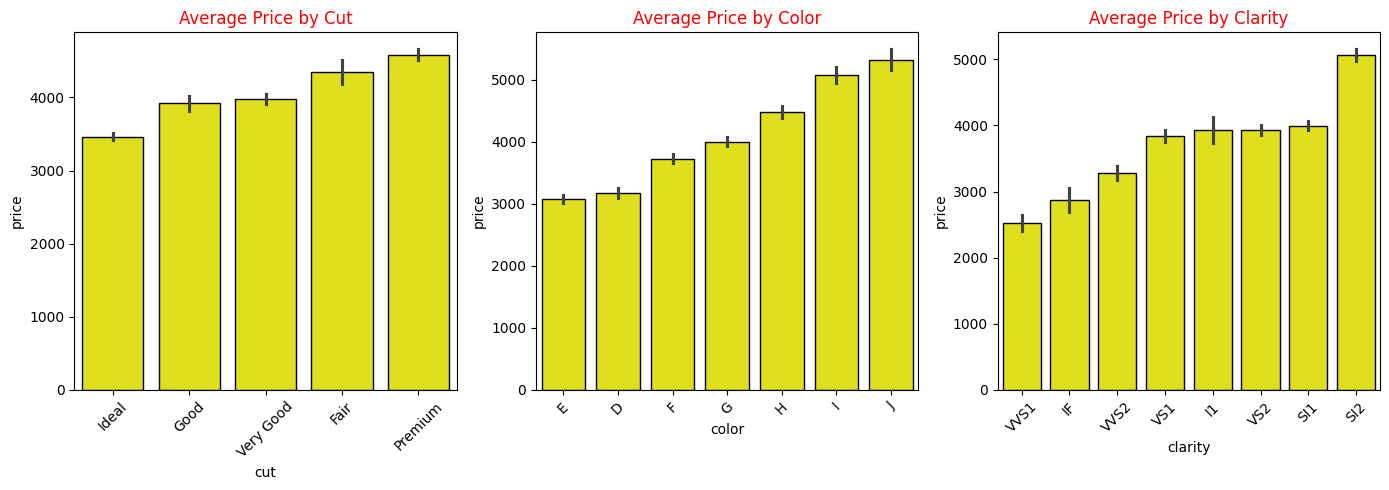

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_style=('whitegrid')
plt.figure(figsize=(14,5))
cat_cols=['cut','color','clarity']
for i,col in enumerate(cat_cols,1):
  plt.subplot(1,3,i)
  order=df.groupby(col)['price'].mean().sort_values().index
  sns.barplot(
      x=col,
      y='price',
      data=df,
      order=order,
      color='yellow',
      edgecolor='black'
  )

  plt.title(f"Average Price by {col.capitalize()}",color='red')
  plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


# **Feature Engineering**

*Converted the price (in USD) to INR using a fixed or dynamic conversion rate*


In [15]:
usd_to_inr=95
df['price_inr']=df['price']*usd_to_inr


*Volume*

In [16]:
df['volume']=df['x']*df['y']*df['z']

*Carat Category*

In [17]:
def carat_category(carat):
  if carat < 0.5:
    return 'Light'
  elif carat <=1.5:
    return 'Medium'
  else:
    return 'Heavy'
df['carat_category']=df['carat'].apply(carat_category)

In [ ]:
df.head()

,carat,cut,color,clarity,depth,table,price,x,y,z,price_inr,volume,carat_category
0,0.23,Ideal,E,SI2,61.5,55.0,326,3.95,3.98,2.43,30970,38.202030,Light
1,0.21,Premium,E,SI1,59.8,61.0,326,3.89,3.84,2.31,30970,34.505856,Light
2,0.23,Good,E,VS1,56.9,65.0,327,4.05,4.07,2.31,31065,38.076885,Light
3,0.29,Premium,I,VS2,62.4,58.0,334,4.20,4.23,2.63,31730,46.724580,Light
4,0.31,Good,J,SI2,63.3,58.0,335,4.34,4.35,2.75,31825,51.917250,Light


In [18]:
df.drop(['x','y','z'],axis=1,inplace=True)

In [19]:
df['volume'].isnull().sum()

np.int64(0)

In [20]:
df['carat_category'].value_counts()

,count
carat_category,
Medium,30768
Light,17608
Heavy,5418


**Train and Test Split**

In [21]:
from sklearn.model_selection import train_test_split
X=df.drop(['price','price_inr'], axis=1)
y=df['price_inr']
X_train,X_test,y_train,y_test=train_test_split(
    X,y,test_size=0.25,random_state=42
)

**Handling Outliers**

In [22]:
num_cols = X_train.select_dtypes(include=['float64']).columns

In [23]:
for col in num_cols:
  Q1=X_train[col].quantile(0.25)
  Q3=X_train[col].quantile(0.75)
  IQR=Q3-Q1

  lower=Q1-1.5*IQR
  upper=Q3+1.5*IQR

  X_train[col]=X_train[col].clip(lower,upper)
  X_test[col]=X_test[col].clip(lower,upper)

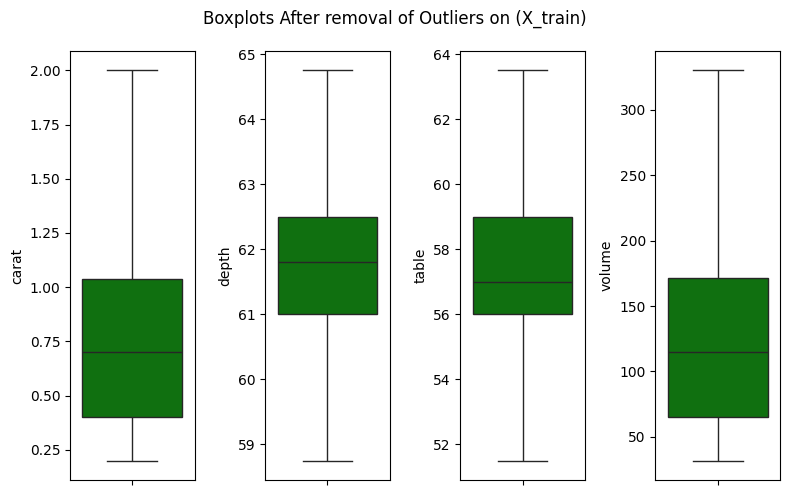

In [24]:
plt.figure(figsize=(8,5))
plt.suptitle("Boxplots After removal of Outliers on (X_train)")
for i in range(0,len(num_cols)):
    plt.subplot(1,len(num_cols),i+1)
    sns.boxplot(y=X_train[num_cols[i]], color='green')
plt.tight_layout()


**Handling Skewness**

In [25]:
skew_cols=['carat','volume']

In [26]:
import numpy as np
for col in skew_cols:
  X_train[col]=np.log1p(X_train[col])
  X_test[col]=np.log1p(X_test[col])

In [27]:
y_train=np.log1p(y_train)
y_test=np.log1p(y_test)

In [28]:
X_train[skew_cols].skew()

,0
carat,0.495478
volume,0.078442


In [29]:
y_train.skew()

np.float64(0.11769529524224824)

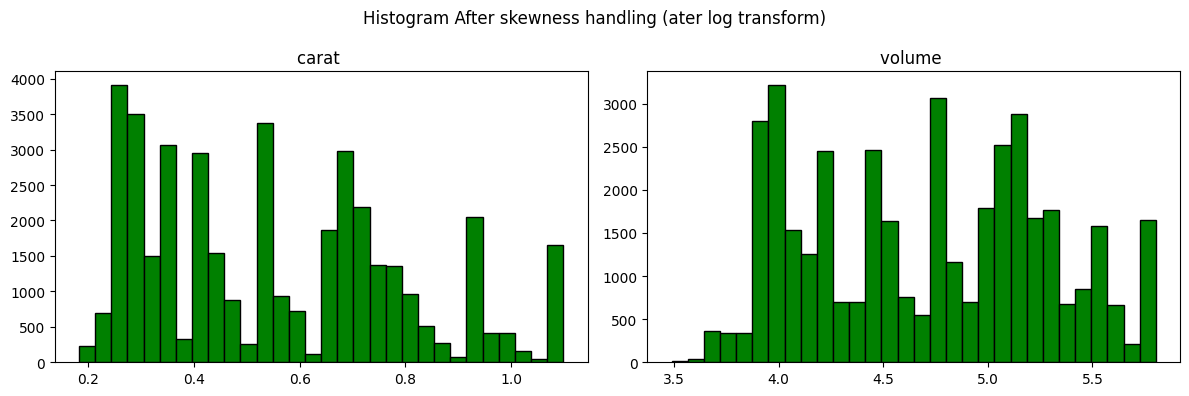

In [30]:
plt.figure(figsize=(12,4))
for i, col in enumerate(skew_cols,1):
  plt.suptitle("Histogram After skewness handling (ater log transform)")
  plt.subplot(1,len(skew_cols),i)
  plt.hist(X_train[col],bins=30,color='green',edgecolor='black')
  plt.title(f"{col} ")
plt.tight_layout()
plt.show()

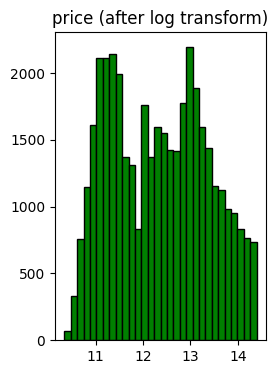

In [31]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
plt.subplot(1,2,2)
plt.hist(y_train, bins=30,color='green',edgecolor='black')
plt.title("price (after log transform)")
plt.show()

# **Encoding**

In [32]:
cat_cols=['cut', 'color', 'clarity']

In [33]:
from sklearn.preprocessing import OneHotEncoder

In [34]:
encoder=OneHotEncoder(drop='first',sparse_output=False)

In [35]:
X_train_cat=encoder.fit_transform(X_train[cat_cols]) #Fit on X_train
X_test_cat=encoder.transform(X_test[cat_cols])   #Transform on X_test

In [36]:
encoded_cols=encoder.get_feature_names_out(cat_cols)
X_train_cat=pd.DataFrame(X_train_cat,columns=encoded_cols,index=X_train.index)
X_test_cat=pd.DataFrame(X_test_cat,columns=encoded_cols,index=X_test.index)

In [37]:
X_train_num=X_train.drop(columns=cat_cols)
X_test_num=X_test.drop(columns=cat_cols)

In [38]:
X_train_final=pd.concat([X_train_num,X_train_cat],axis=1)
X_test_final=pd.concat([X_test_num,X_test_cat],axis=1)

In [39]:
X_train_final.head()

,carat,depth,table,volume,carat_category,cut_Good,cut_Ideal,cut_Premium,cut_Very Good,color_E,...,color_H,color_I,color_J,clarity_IF,clarity_SI1,clarity_SI2,clarity_VS1,clarity_VS2,clarity_VVS1,clarity_VVS2
12820,0.703098,62.4,57.0,5.109556,Medium,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
19997,0.717840,61.3,59.0,5.141869,Medium,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
6099,0.647103,62.6,58.0,4.989430,Medium,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
37984,0.277632,60.9,57.0,3.984266,Light,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
24865,0.924259,61.9,56.0,5.502271,Heavy,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0


In [ ]:
import joblib
joblib.dump(encoder,'/content/drive/MyDrive/onehotencoder_diamond.pkl')

['/content/drive/MyDrive/onehotencoder_diamond.pkl']

**Ordinal Encoder for Carat Category Column**

In [40]:
from sklearn.preprocessing import OrdinalEncoder

In [41]:
ord_encoder=OrdinalEncoder(categories=[['Light','Medium','Heavy']])

In [42]:
X_train['carat_category']=ord_encoder.fit_transform(X_train[['carat_category']])
X_test['carat_category']=ord_encoder.transform(X_test[['carat_category']])

In [ ]:
import joblib
joblib.dump(ord_encoder,'/content/drive/MyDrive/ordinalencoder_diamond.pkl')

['/content/drive/MyDrive/ordinalencoder_diamond.pkl']

# **Feature Selection**


***Feature Importance By using model Random Forest ***

In [43]:
original_features = ['cut', 'color', 'clarity', 'carat_category',
                     'carat', 'depth', 'table', 'volume']

In [44]:
from sklearn.ensemble import RandomForestRegressor

# Re-create X_train_num and X_test_num using the updated X_train and X_test
X_train_num=X_train.drop(columns=cat_cols)
X_test_num=X_test.drop(columns=cat_cols)

# Re-create X_train_final and X_test_final
X_train_final=pd.concat([X_train_num,X_train_cat],axis=1)
X_test_final=pd.concat([X_test_num,X_test_cat],axis=1)

rf = RandomForestRegressor(random_state=42)

# Use encoded data ✅
rf.fit(X_train_final, y_train)

feat_imp = pd.Series(rf.feature_importances_, index=X_train_final.columns)
grouped_importance={}
for col in feat_imp.index:
  matched=False
  for base in original_features:
    if col.startswith(base):
     grouped_importance[base]=grouped_importance.get(base,0)+feat_imp[col]
     matched=True
  if not matched:
     grouped_importance[col]=grouped_importance.get(col,0)+feat_imp[col]
grouped_importance=pd.Series(grouped_importance).sort_values(ascending=False)
print(grouped_importance)


volume            0.900385
carat             0.047630
clarity           0.028152
color             0.015317
depth             0.004363
cut               0.002193
table             0.001960
carat_category    0.000192
dtype: float64


In [45]:
selected_features=grouped_importance.sort_values(ascending=False).head(8).index
selected_features

Index(['volume', 'carat', 'clarity', 'color', 'depth', 'cut', 'table',
       'carat_category'],
      dtype='object')

In [ ]:
import joblib
joblib.dump(selected_features,'/content/drive/MyDrive/features.pkl')

['/content/drive/MyDrive/features.pkl']

In [46]:
final_cols = []

for col in X_train_final.columns:
    base = col.split('_')[0] if '_' in col else col
    if base in selected_features:
        final_cols.append(col)

X_train_selected = X_train_final[final_cols]
X_test_selected = X_test_final[final_cols]

In [47]:
import joblib

# Save the final_cols list which contains all the specific encoded feature names
joblib.dump(final_cols, '/content/drive/MyDrive/model_final_feature.pkl')

['/content/drive/MyDrive/model_final_feature.pkl']

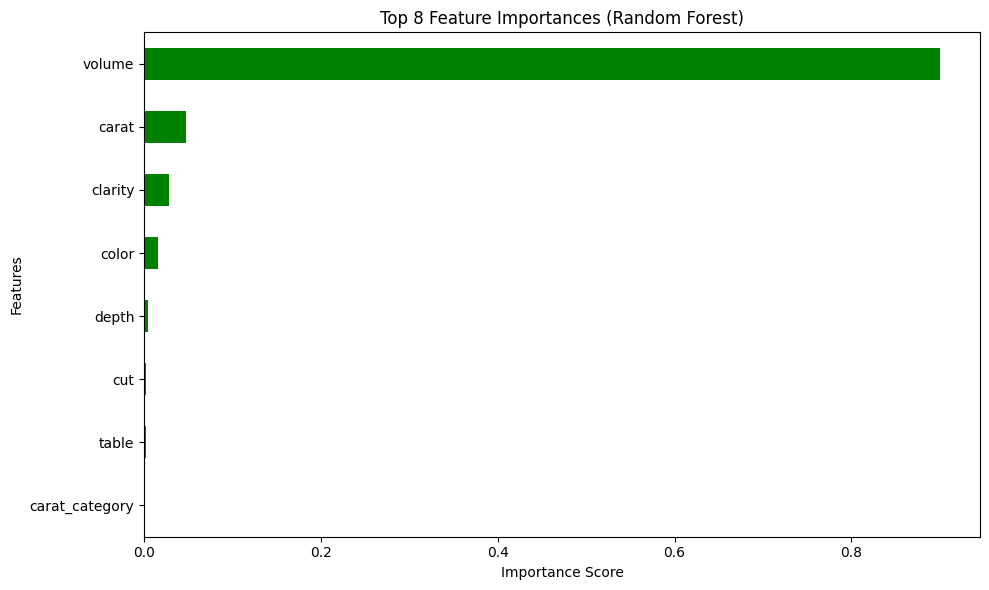

In [ ]:
top_features=grouped_importance.sort_values(ascending=False).head(8)
plt.figure(figsize=(10,6))
top_features.sort_values().plot(kind='barh',color='green')


plt.title("Top 8 Feature Importances (Random Forest)")
plt.xlabel("Importance Score")
plt.ylabel("Features")


plt.tight_layout()
plt.show()

***Scaling required for Both model building Linear Regression and KNN ***

**Scaling**

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler=StandardScaler()
X_train_scaled=scaler.fit_transform(X_train_selected)
X_test_scaled=scaler.transform(X_test_selected)

In [ ]:
import joblib
joblib.dump(scaler,'/content/drive/MyDrive/scaler_feature.pkl')

['/content/drive/MyDrive/scaler_feature.pkl']

**Linear Regression**

In [ ]:
from sklearn.linear_model import LinearRegression
lr=LinearRegression()
lr.fit(X_train_scaled,y_train)
lr_pred=lr.predict(X_test_scaled)


**Random Forest**

In [ ]:
from sklearn.ensemble import RandomForestRegressor
rf=RandomForestRegressor(n_estimators=200,random_state=42)
rf.fit(X_train_selected,y_train)
rf_pred=rf.predict(X_test_selected)


**Decision Tree**

In [ ]:
from sklearn.tree import DecisionTreeRegressor
dt=DecisionTreeRegressor(random_state=42)
dt.fit(X_train_selected,y_train)
dt_pred=dt.predict(X_test_selected)


**XGBoost**

In [ ]:
from xgboost import XGBRegressor
xgb=XGBRegressor(n_estimators=200,random_state=42)
xgb.fit(X_train_selected,y_train)
xgb_pred=xgb.predict(X_test_selected)

**KNN**

In [ ]:
from sklearn.neighbors import KNeighborsRegressor
knn=KNeighborsRegressor(n_neighbors=5)
knn.fit(X_train_scaled,y_train)
knn_pred=knn.predict(X_test_scaled)

**Evaluation for the models**

In [ ]:
from sklearn.metrics import r2_score,mean_absolute_error,mean_squared_error
import numpy as np

def evaluate_model(name,y_true,y_pred):
  print(f"\n{name}")
  print("R2:",r2_score(y_true,y_pred))
  print("MAE:",mean_absolute_error(y_true,y_pred))
  print("RMSE:",np.sqrt(mean_squared_error(y_true,y_pred)))

In [ ]:
evaluate_model("Linear Regression:",y_test,lr_pred)
evaluate_model("Random Forest:",y_test,rf_pred)
evaluate_model("Decision Tree:",y_test,dt_pred)
evaluate_model("XGBoost:",y_test,xgb_pred)
evaluate_model("KNN:",y_test,knn_pred)


Linear Regression:
R2: 0.9815856514574554
MAE: 0.10398618741757101
RMSE: 0.13636098431192598

Random Forest:
R2: 0.985295349436572
MAE: 0.08664097887753483
RMSE: 0.12185386313889095

Decision Tree:
R2: 0.9742187705009948
MAE: 0.10894219083079794
RMSE: 0.16134806461686588

XGBoost:
R2: 0.9896663871591767
MAE: 0.07600572925355481
RMSE: 0.10214992240018905

KNN:
R2: 0.9641431141086557
MAE: 0.13393585050527698
RMSE: 0.1902822300165284


In [ ]:
results={
    "Model:":["Linear Regression","Random Forest","Decision Tree","XGBoost","KNN"],
    "R2 Score:":[
        r2_score(y_test,lr_pred),
        r2_score(y_test,rf_pred),
        r2_score(y_test,dt_pred),
        r2_score(y_test,xgb_pred),
        r2_score(y_test,knn_pred)
    ]
}

import pandas as pd
result_df=pd.DataFrame(results)
print(result_df)

              Model:  R2 Score:
0  Linear Regression   0.981586
1      Random Forest   0.985295
2      Decision Tree   0.974219
3            XGBoost   0.989666
4                KNN   0.964143


In [ ]:
print("Train R2:", xgb.score(X_train_selected, y_train))
print("Test R2:", xgb.score(X_test_selected, y_test))

Train R2: 0.9931295031626006
Test R2: 0.9896663871591767


In [ ]:
import joblib
joblib.dump(xgb,'/content/drive/MyDrive/xgb_final.pkl')

['/content/drive/MyDrive/xgb_final.pkl']

In [ ]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from xgboost import XGBRegressor

# Columns
onehot_cols = ['cut','color','clarity']
ordinal_cols = ['carat_category']
numeric_cols = ['volume','carat','depth','table']

preprocessor = ColumnTransformer([
    ('onehot', OneHotEncoder(handle_unknown='ignore'), onehot_cols),
    ('ordinal', OrdinalEncoder(), ordinal_cols),
    ('num', StandardScaler(), numeric_cols)
])

pipeline = Pipeline([
    ('preprocessing', preprocessor),
    ('model', XGBRegressor())
])

pipeline.fit(X_train, y_train)

Pipeline(steps=[('preprocessing',
                 ColumnTransformer(transformers=[('onehot',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['cut', 'color', 'clarity']),
                                                 ('ordinal', OrdinalEncoder(),
                                                  ['carat_category']),
                                                 ('num', StandardScaler(),
                                                  ['volume', 'carat', 'depth',
                                                   'table'])])),
                ('model',
                 XGBRegressor(base_score=None, booster=None, callbacks=None,
                              colsample_bylevel=None, colsample...
                              feature_types=None, feature_weights=None,
                              gamma=None, grow_policy=None,
                              importance_type=None,
                              interaction_constraints=None, learning_rate=None,
                              max_bin=None, max_cat_threshold=None,
                              max_cat_to_onehot=None, max_delta_step=None,
                              max_depth=None, max_leaves=None,
                              min_child_weight=None, missing=nan,
                              monotone_constraints=None, multi_strategy=None,
                              n_estimators=None, n_jobs=None,
                              num_parallel_tree=None, ...))])

In [ ]:
import joblib
joblib.dump(pipeline, '/content/drive/MyDrive/diamond_pipeline.pkl')

['/content/drive/MyDrive/diamond_pipeline.pkl']

In [ ]:
import sklearn
import xgboost
import numpy
import pandas

print("sklearn:", sklearn.__version__)
print("xgboost:", xgboost.__version__)
print("numpy:", numpy.__version__)
print("pandas:", pandas.__version__)

sklearn: 1.6.1
xgboost: 3.2.0
numpy: 2.0.2
pandas: 2.2.2


In [ ]:
pip install scikit-learn==1.6.1
pip install xgboost==3.2.0
pip install numpy==2.0.2
pip install pandas==2.2.2

**ANN regression model**


In [ ]:
X_train_ann=X_train_scaled
X_test_ann=X_test_scaled

In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

In [ ]:
ann = Sequential()
ann.add(Dense(units=64, activation='relu',input_shape=(X_train_ann.shape[1],))) # Input layer + 1st hidden layer
ann.add(Dense(units=32, activation='relu')) # 2nd hidden layer
ann.add(Dense(units=16, activation='relu')) # 3rd hidden layer
ann.add(Dense(1)) # Output layer
ann.compile(optimizer='adam', loss='mean_squared_error')

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
ann.fit(X_train_ann,y_train,epochs=50,batch_size=32,verbose=1)

Epoch 1/50
1261/1261 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - loss: 4.4120 
Epoch 2/50
1261/1261 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - loss: 0.0444
Epoch 3/50
1261/1261 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - loss: 0.0286
Epoch 4/50
1261/1261 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - loss: 0.0242
Epoch 5/50
1261/1261 ━━━━━━━━━━━━━━━━━━━━ 6s 5ms/step - loss: 0.0228
Epoch 6/50
1261/1261 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - loss: 0.0216
Epoch 7/50
1261/1261 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - loss: 0.0212
Epoch 8/50
1261/1261 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - loss: 0.0204
Epoch 9/50
1261/1261 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - loss: 0.0205
Epoch 10/50
1261/1261 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - loss: 0.0191
Epoch 11/50
1261/1261 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - loss: 0.0190
Epoch 12/50
1261/1261 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - loss: 0.0184
Epoch 13/50
1261/1261 ━━━━━━━━━━━━━━━━━━━━ 9s 4ms/step - loss: 0.0187
Epoch 14/50
1261/1261 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - loss: 0.0184
Epoch 15/50
1261/1261 ━━━━━━

In [ ]:
ann_pred=ann.predict(X_test_ann).flatten()

421/421 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step


In [ ]:
from sklearn.metrics import r2_score,mean_absolute_error,mean_squared_error
import numpy as np

print("ANN Results")
print("R2:",r2_score(y_test,ann_pred))
print("MAE:",mean_absolute_error(y_test,ann_pred))
print("RMSE:",np.sqrt(mean_squared_error(y_test,ann_pred)))

ANN Results
R2: 0.9839780558597929
MAE: 0.09583812564654119
RMSE: 0.12719485792720064


In [ ]:
result_df.loc[len(result_df)]=[
    "ANN",
    r2_score(y_test,ann_pred)
]

In [ ]:
print(result_df)

              Model:  R2 Score:
0  Linear Regression   0.981486
1      Random Forest   0.985115
2      Decision Tree   0.973950
3            XGBoost   0.989420
4                KNN   0.974151
5                ANN   0.983978


# **Clustering (Market Segmentation)**


In [51]:
import pandas as pd

In [52]:
path='/content/drive/MyDrive/diamonds.csv'
df_cluster=pd.read_csv(path)

In [53]:
df_cluster

,carat,cut,color,clarity,depth,table,price,x,y,z
0,0.23,Ideal,E,SI2,61.5,55.0,326,3.95,3.98,2.43
1,0.21,Premium,E,SI1,59.8,61.0,326,3.89,3.84,2.31
2,0.23,Good,E,VS1,56.9,65.0,327,4.05,4.07,2.31
3,0.29,Premium,I,VS2,62.4,58.0,334,4.20,4.23,2.63
4,0.31,Good,J,SI2,63.3,58.0,335,4.34,4.35,2.75
...,...,...,...,...,...,...,...,...,...,...
53935,0.72,Ideal,D,SI1,60.8,57.0,2757,5.75,5.76,3.50
53936,0.72,Good,D,SI1,63.1,55.0,2757,5.69,5.75,3.61
53937,0.70,Very Good,D,SI1,62.8,60.0,2757,5.66,5.68,3.56
53938,0.86,Premium,H,SI2,61.0,58.0,2757,6.15,6.12,3.74


In [54]:
df_cluster=df_cluster.drop_duplicates() #Removing Duplicates

In [55]:
df_cluster=df_cluster[(df_cluster['x'] > 0 ) & (df_cluster ['y'] > 0) & (df_cluster ['z'] > 0)] #remove invalid dimension

In [56]:
df_cluster['volume'] = df_cluster['x'] * df_cluster['y'] * df_cluster['z']

In [57]:
df_cluster_1=df_cluster[['carat','depth','table','price','cut','color','clarity','volume']].copy()  #Feature Selection for Clustering

In [ ]:
from sklearn.preprocessing import OrdinalEncoder
encoder=OrdinalEncoder()
df_cluster_1[['cut','color','clarity']]=encoder.fit_transform(df_cluster_1[['cut','color','clarity']])

In [ ]:
num_cols = ['carat', 'depth', 'table', 'price', 'volume']    #Outliers Handling

for col in num_cols:
  Q1 = df_cluster_1[col].quantile(0.25)
  Q3 = df_cluster_1[col].quantile(0.75)
  IQR = Q3 - Q1
  lower = Q1 - 1.5 * IQR
  upper = Q3 + 1.5 * IQR
  df_cluster_1[col] = df_cluster_1[col].clip(lower, upper)

In [ ]:
from sklearn.preprocessing import StandardScaler  #Scaling done here
cluster_scaler=StandardScaler()
X_scaled_cluster=cluster_scaler.fit_transform(df_cluster_1)

In [ ]:
from sklearn.preprocessing import OrdinalEncoder
cluster_encoder=OrdinalEncoder()
df_cluster_1[['cut','color','clarity']]=cluster_encoder.fit_transform(df_cluster_1[['cut','color','clarity']])

In [ ]:
num_cols = ['carat', 'depth', 'table', 'price', 'volume']    #Outliers Handling

for col in num_cols:
  Q1 = df_cluster_1[col].quantile(0.25)
  Q3 = df_cluster_1[col].quantile(0.75)
  IQR = Q3 - Q1
  lower = Q1 - 1.5 * IQR
  upper = Q3 + 1.5 * IQR
  df_cluster_1[col] = df_cluster_1[col].clip(lower, upper)

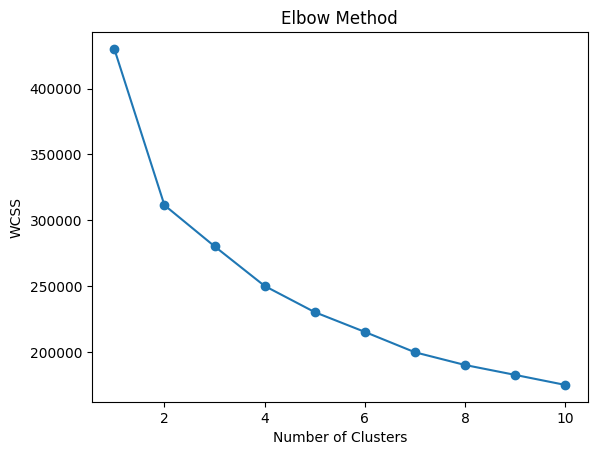

In [ ]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
wccs=[]
for i in range (1,11):
  kmeans=KMeans(n_clusters=i, init='k-means++', random_state=42, n_init='auto')
  kmeans.fit(X_scaled_cluster)
  wccs.append(kmeans.inertia_)
plt.plot(range(1,11),wccs,marker='o')
plt.title("Elbow Method")
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")
plt.show()

In [ ]:
kmeans=KMeans(n_clusters=3,random_state=42)
df_cluster_1['cluster']=kmeans.fit_predict(X_scaled_cluster)

In [ ]:
from sklearn.cluster import DBSCAN
dbscan=DBSCAN(eps=1.5,min_samples=10)
db_labels=dbscan.fit_predict(X_scaled_cluster)
df_cluster_1['db_cluster']=db_labels

In [ ]:
print(df_cluster_1['db_cluster'].value_counts())

db_cluster
 0    53729
-1       46
Name: count, dtype: int64


In [ ]:
import joblib
joblib.dump(kmeans,'/content/drive/MyDrive/kmeans_model.pkl')

['/content/drive/MyDrive/kmeans_model.pkl']

In [ ]:
import joblib
joblib.dump(cluster_scaler,'/content/drive/MyDrive/scaler_cluster.pkl')

['/content/drive/MyDrive/scaler_cluster.pkl']

In [ ]:
import joblib
joblib.dump(cluster_encoder,'/content/drive/MyDrive/encoder_cluster.pkl')

['/content/drive/MyDrive/encoder_cluster.pkl']

In [ ]:
cluster_summary=df_cluster_1.groupby('cluster').agg({
    'price':'mean',
    'carat':'mean',
    'cut':'mean'
})

print(cluster_summary)

                price     carat       cut
cluster                                  
0         4477.572342  0.965068  2.606667
1         1270.639875  0.436382  2.504809
2        10331.843257  1.602967  2.602152


In [ ]:
def name_cluster(cluster):
  if cluster==0:
    return "Premium Heavy Diamond"
  elif cluster==1:
    return "Mid-range Balanced Diamonds"
  else:
    return "Affordable Small Diamonds"

df_cluster_1['segment']=df_cluster_1['cluster'].apply(name_cluster)


In [ ]:
df_cluster_1[['cluster','segment']].head()

,cluster,segment
0,1,Mid-range Balanced Diamonds
1,1,Mid-range Balanced Diamonds
2,1,Mid-range Balanced Diamonds
3,1,Mid-range Balanced Diamonds
4,1,Mid-range Balanced Diamonds


In [58]:
import joblib

# Save the list of feature names from df_cluster_1
clustering_feature_names = df_cluster_1.columns.tolist()
joblib.dump(clustering_feature_names, '/content/drive/MyDrive/clustering_feature_names.pkl')


['/content/drive/MyDrive/clustering_feature_names.pkl']

In [ ]:
cluster_map={
    0:"Premium Heavy Diamond",
    1:"Mid-range Balanced Diamonds",
    2:"Affordable Small Diamonds"
}

In [ ]:
import joblib
joblib.dump(cluster_map,'/content/drive/MyDrive/cluster_map.pkl')

['/content/drive/MyDrive/cluster_map.pkl']